# Project 13 - Reasoning Models & Reinforcement Learning (GRPO)

**A self-explanatory Kaggle notebook.** Each code cell is explained in plain English above it.

Reasoning models (DeepSeek-R1 and its successors) are the headline AI story of 2025-2026: models
trained to **think step-by-step** before answering. The training trick is **reinforcement learning
with verifiable rewards (RLVR)**, often using **GRPO**. We build a tiny, runnable GRPO trainer here
so you understand *why* RL makes a model reason, then give you the real TRL code for a GPU.

**What you'll learn**
- **RL with verifiable rewards:** reward = "is the final answer correct?" (checkable automatically).
- **GRPO** intuition: sample a *group* of answers, reward them, and push the model toward the
  above-average ones - no separate critic needed.
- **Reward hacking:** how a badly designed reward makes the model game it instead of solving the task.

## The scenario
You want a model that solves grade-school maths reliably. You can't easily label "good reasoning",
but you CAN check the final answer automatically (does it equal the known result?). That single
checkable signal - a **verifiable reward** - is enough for RL to teach the model to reason.

## Foundations (plain English)
- **Policy:** the model's strategy for producing an answer. We represent it as a probability over a
  few "strategies" (guess, short reasoning, step-by-step).
- **Verifiable reward:** +1 if the final answer is correct (we can check it), so no human labels are
  needed. This is what makes maths/code ideal RL tasks.
- **GRPO (Group Relative Policy Optimization):** for each problem, sample a **group** of answers,
  score them, and compute each one's **advantage** = its reward minus the group's average. Increase
  the probability of above-average answers, decrease below-average ones. (Group-relative = no
  separate value network, which is why it's efficient and popular for reasoning.)
- **Reward hacking:** models optimise exactly what you reward. If you over-reward "looking thorough"
  (length) instead of correctness, the model learns to ramble - and gets *worse*.

### Cell 1 - the task, strategies, and reward
Four strategies differ in how accurate they are and how long/'thorough' they look. Step-by-step is
both accurate AND fairly long; padded-wrong is very long but usually wrong (our future hacker).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# strategy:        (name,            P(correct),  'length'/thoroughness)
STRAT = [("guess",          0.20, 0.1),
         ("short_reason",   0.60, 0.5),
         ("step_by_step",   0.95, 1.0),
         ("padded_wrong",   0.20, 3.0)]
names  = [s[0] for s in STRAT]
acc    = np.array([s[1] for s in STRAT])
length = np.array([s[2] for s in STRAT])

def softmax(z): z=z-z.max(); e=np.exp(z); return e/e.sum()
print("strategies:", names)

strategies: ['guess', 'short_reason', 'step_by_step', 'padded_wrong']


### Cell 2 - a tiny GRPO training loop
Each step: sample a GROUP of answers from the current policy, give each a **verifiable reward**
(1 if correct) plus a small length bonus, compute the **group-relative advantage**, and nudge the
policy logits toward higher-advantage strategies. Watch the policy learn to reason.

In [2]:
def train(format_weight, iters=400, G=16, lr=0.2, seed=0):
    rng = np.random.default_rng(seed)
    logits = np.zeros(len(STRAT))
    correctness_hist = []
    for _ in range(iters):
        p = softmax(logits)
        group = rng.choice(len(STRAT), size=G, p=p)               # sample a group of answers
        correct = (rng.random(G) < acc[group]).astype(float)      # VERIFIABLE reward: right or not
        reward = correct + format_weight * length[group]          # (+ a length/format bonus)
        advantage = reward - reward.mean()                        # GRPO: relative to the GROUP mean
        for s, a in zip(group, advantage):
            logits[s] += lr * a                                   # push policy toward better-than-average
        correctness_hist.append(correct.mean())
    return softmax(logits), correctness_hist

final_p, hist = train(format_weight=0.05)                          # a sensible reward
print("final policy (probability of each strategy):")
for n, pr in zip(names, final_p): print(f"  {n:14s} {pr:.2f}")

final policy (probability of each strategy):
  guess          0.00
  short_reason   0.00
  step_by_step   1.00
  padded_wrong   0.00


### Cell 3 - diagram: the model learns to reason
Average correctness of sampled answers over training. It climbs from ~chance toward ~0.95 as RL
pushes the policy onto the **step-by-step** strategy - because that's what earns the reward.

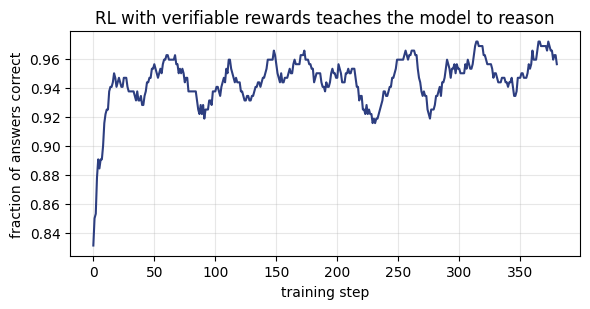

In [3]:
sm = np.convolve(hist, np.ones(20)/20, mode="valid")     # smooth the noisy reward
plt.figure(figsize=(6,3.2))
plt.plot(sm, color="#2d3e80")
plt.xlabel("training step"); plt.ylabel("fraction of answers correct")
plt.title("RL with verifiable rewards teaches the model to reason"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Cell 4 - diagram: where the policy ended up
The final probability of each strategy. The model concentrated on **step-by-step reasoning** - it
discovered, purely from the reward, that thinking before answering pays off.

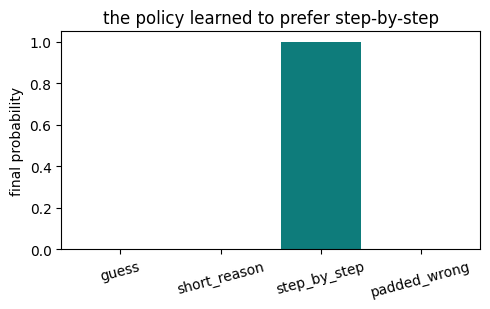

In [4]:
plt.figure(figsize=(5,3.2))
colors=["#c9ced9","#9aa3bd","#0e7c7b","#b3261e"]
plt.bar(names, final_p, color=colors)
plt.ylabel("final probability"); plt.title("the policy learned to prefer step-by-step")
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

### Cell 5 - diagram: reward hacking (why reward design matters)
Now we crank the **length bonus** way up. The model discovers it can score high by being long
(`padded_wrong`) instead of correct - so real correctness *drops*. The reward looks great; the
model got worse. This is the central danger of RL, and why verifiable correctness must dominate.

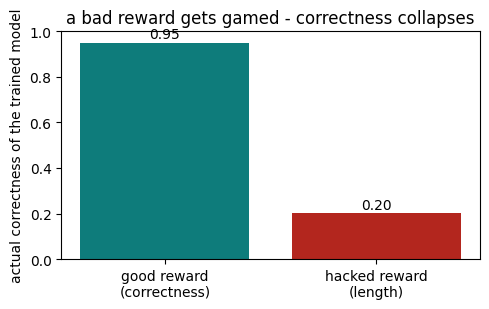

P(padded_wrong): good reward=0.00  vs  hacked reward=1.00


In [5]:
good_p, _ = train(format_weight=0.05)     # correctness-focused reward
hack_p, _ = train(format_weight=0.7)      # over-rewards length
# 'true correctness' of each final policy = sum(prob * P(correct))
good_correct = float((good_p * acc).sum())
hack_correct = float((hack_p * acc).sum())
plt.figure(figsize=(5,3.2))
plt.bar(["good reward\n(correctness)","hacked reward\n(length)"], [good_correct, hack_correct],
        color=["#0e7c7b","#b3261e"])
plt.ylabel("actual correctness of the trained model"); plt.ylim(0,1)
plt.title("a bad reward gets gamed - correctness collapses")
for i,v in enumerate([good_correct, hack_correct]): plt.text(i, v+0.02, f"{v:.2f}", ha="center")
plt.tight_layout(); plt.show()
print(f"P(padded_wrong): good reward={good_p[3]:.2f}  vs  hacked reward={hack_p[3]:.2f}")

## The real thing - GRPO on a GPU with TRL
On a real model you sample full text answers, parse the final number, and reward correctness.
TRL's `GRPOTrainer` handles the group sampling and updates.

```python
# pip install trl transformers peft datasets
import re
from datasets import load_dataset
from trl import GRPOConfig, GRPOTrainer

def reward_correct(completions, answer, **kwargs):
    out = []
    for c, a in zip(completions, answer):
        m = re.search(r"####\s*(-?\d+)", c)                 # parse the model's final answer
        out.append(1.0 if (m and m.group(1) == str(a)) else 0.0)   # verifiable reward
    return out

data = load_dataset("openai/gsm8k", "main", split="train")   # maths problems with checkable answers
trainer = GRPOTrainer(
    model="Qwen/Qwen2.5-0.5B-Instruct",
    reward_funcs=[reward_correct],
    args=GRPOConfig(num_generations=8, per_device_train_batch_size=8, report_to="wandb"),
    train_dataset=data)
trainer.train()                          # the model learns to show working and answer correctly
```

**Make it a project:** measure pass@1 on held-out problems (base vs trained), watch reward AND
response length (catch reward hacking), and write up what the model learned - and gamed.

## What just happened (recap)
- A **verifiable reward** (is the answer correct?) needs no human labels - perfect for maths/code.
- **GRPO** samples a group, computes each answer's advantage vs the group mean, and pushes the
  policy toward better-than-average answers. Our toy policy **learned to reason** (you saw the
  correctness curve climb and the strategy bar concentrate on step-by-step).
- **Reward hacking** is real: over-reward length and the model games it, hurting true correctness.

## Scenarios & your turn
- **Change the reward:** raise/lower `format_weight` in Cell 5 - find where hacking kicks in.
- **Harder task:** add more strategies or noisier accuracies and see if RL still finds the best.
- **Group size:** try G=4 vs G=32 - bigger groups give steadier advantages.
- **Project goal:** run TRL GRPO on a small model + GSM8K, report pass@1 gains, and discuss any
  reward hacking you observe.

## Mini-glossary
**reasoning model** thinks step-by-step before answering - **chain-of-thought** the intermediate
steps - **RLVR** RL with verifiable rewards - **GRPO** group-relative policy optimization (no
critic) - **policy** the answer-producing strategy - **advantage** reward minus the group mean -
**reward hacking** exploiting the reward instead of solving the task - **pass@1** correct on the
first try.